# Cyclistic Bike-Share Analysis
## Case Study: How do annual members and casual riders use Cyclistic bikes differently?

### Background
Cyclistic is a bike-share company in Chicago. The goal of this analysis is to identify behavioral differences between annual members and casual riders, in order to develop marketing strategies to convert casual riders into members.

### Business Question
How do annual members and casual riders use Cyclistic bikes differently?

## Ask
Based on the analysis of the interaction between different types of users with the system, in this case annual members and occasional users, we will be able to identify trends that help us develop marketing strategies that encourage casual users to obtain an annual membership.
### Key Stakeholders
Key stakeholders involved into this analysis are Cyclistic Executive Team, Director of Marketing and Cyclistic marketing analytic team

## Prepare
The data used for this analysis is a public data made by Motivate International Inc. Under a license provided by Lyft Bikes and Scooters, LLC (“Bikeshare”) and it comes from the Divvy system data owned by the City (“Data”). This information covers data from may 2025 to may 2026 where each month is a CSV spreadsheet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import glob #this library searches files using patterns
import os #This library is useful for working with paths and folders
#Create a new variable called 'all_files'
#glob.glob('...') searches CSV files in a folder and subfolders
#Use a list comprehension in order to filter Mac files such '._files.csv' of CSV files
all_files = [f for f in glob.glob(r'C:\Users\brabe\Desktop\Coursera\Capstone\Data/**/*.csv', recursive=True)
             if not os.path.basename(f).startswith('._')]
#Print shows how many files are
print(f"files found: {len(all_files)}")
#a for that goes through all_files and prints each element:
for file in all_files:
        print(file)

files found: 13
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202504-divvy-tripdata\202504-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202505-divvy-tripdata\202505-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202506-divvy-tripdata\202506-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202507-divvy-tripdata\202507-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202508-divvy-tripdata\202508-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202509-divvy-tripdata\202509-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202510-divvy-tripdata\202510-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202511-divvy-tripdata\202511-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202512-divvy-tripdata\202512-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Data\202601-divvy-tripdata\202501-divvy-tripdata.csv
C:\Users\brabe\Desktop\Coursera\Capstone\Dat

In [3]:
data_files = [pd.read_csv(f) for f in all_files] #for the data frame data_files load a file for eachfile in all_files
df = pd.concat(data_files, ignore_index=True) #create a new dataframe 'df' and join all the files with pd.concat
print(f"Total rows: {df.shape[0]}") #print the total number of rows and the total number of columns
print(f"Total columns: {df.shape[1]}")
df.head() # show the first five lines              

Total rows: 6068796
Total columns: 13


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068796 entries, 0 to 6068795
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 601.9+ MB


In [5]:
df.isnull().sum() #show null values

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1286941
start_station_id      1286941
end_station_name      1353498
end_station_id        1353498
start_lat                   0
start_lng                   0
end_lat                  6146
end_lng                  6146
member_casual               0
dtype: int64

## Process
The information obtained from the data collected and concatenated show us that there are two different data type which are 'object' and 'float', a data transformation from 'object' type to 'datetime' is needed in columns like 'started_at' and 'ended_at' in order to perform the correct analysis. In the same way we noticed several null values in station columns which will affect a properly subsequent analysis, therefore data cleaning will be requeried eventually.

In [6]:
# select a column and pd.to_datetime converts to date format
df['started_at'] = pd.to_datetime(df['started_at']) 
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068796 entries, 0 to 6068795
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 601.9+ MB


In [8]:
# Calculate ride duration by subtracting start time from end time
df['ride_length'] = (df['ended_at']-df['started_at'])

In [9]:
# Convert ride duration to minutes as a float
df['ride_length'] = df['ride_length'] / pd.Timedelta(minutes=1)
df['ride_length'].head()

0     6.816083
1    10.235867
2    10.153117
3    10.026767
4    10.060817
Name: ride_length, dtype: float64

In [10]:
df['day_of_week'] = (df['started_at'].dt.day_of_week) # Extract the day of week from started_at column
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member,6.816083,6
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member,10.235867,2
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member,10.153117,5
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member,10.026767,3
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member,10.060817,1


In [11]:
print (df[df['ride_length'] <= 0].shape[0]) # Calculate how many rows have ride_lenght less than or equal to zero 

29


There are 29 rows in six million where the ride lenght is less than or equal to zero. It means incorrect data in columns 'started_at' and ended_at'. Needs to be fixed by boolean masking

In [12]:
df = df[df['ride_length'] > 0] # Create a filter to get all values more than zero
print(f"Total rows after cleaning: {df.shape[0]}")

Total rows after cleaning: 6068767


In [13]:
df.duplicated().sum() # Check duplicates

np.int64(0)

After checking for duplicates, it is determined that there are no duplicates

In [14]:
print(df['ride_length'].describe()) #check maximum values to discard inconsistencies in the data

count    6.068767e+06
mean     1.591308e+01
std      5.522242e+01
min      7.666667e-04
25%      5.342225e+00
50%      9.341283e+00
75%      1.643302e+01
max      1.574900e+03
Name: ride_length, dtype: float64


It can be observed that the average trip duration is 15 minutes, which is normal. But the maximum value is 1574 minutes, which equates to 26 hours. Therefore, we will initially check how many trips last more than 24 hours.

In [15]:
print(df[df['ride_length'] > 1440].shape[0])

6133


6,133 trips of more than 24 hours — that is a significant but small amount compared to 6 million. Most likely, they are bikes not returned properly. For the analysis, we are going to remove them because they would distort the average duration. We will make a filter to keep just trips with 1440 minutos or less than

In [16]:
df = df[df['ride_length'] < 1440] # make a filter to keep just trips with 1440 minutos or less than
print(f"Total rows after cleaning: {df.shape[0]}") # Check how many rows are now

Total rows after cleaning: 6062634


In summary, we carried out the following cleaning process
1. Data type conversion
2. Creation of new columns
3. Removal of ride_length <= 0
4. Duplicate check
5. Removal of trips longer than 24 hours

## Analyze
Once we got all the data cleaned, organized and properly formatted we can proceed to perfom calculations in order to get a comparision of the behavior of members vs casual users.

In [17]:
print(f"Total rows: {df.shape[0]}") #print the total number of rows and the total number of columns
print(f"Total columns: {df.shape[1]}")
df.head()

Total rows: 6062634
Total columns: 15


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member,6.816083,6
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member,10.235867,2
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member,10.153117,5
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member,10.026767,3
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member,10.060817,1


In [18]:
df['member_casual'].value_counts() #to count how many members and how many casual users there are

member_casual
member    3920692
casual    2141942
Name: count, dtype: int64

The data shows **3,920,692 member rides** compared to **2,141,942 casual rides**, indicating that members take nearly twice as many trips. This suggests that the service is primarily used for daily commuting rather than occasional leisure. Based on this insight, the company can develop targeted strategies to encourage casual riders to adopt the service as a reliable option for everyday transportation, not just for recreational use.

In [19]:
df.groupby('member_casual')['ride_length'].mean() #we will obtain the average of ride_length for members vs casuals, using df.groupby

member_casual
casual    18.909893
member    11.955500
Name: ride_length, dtype: float64

When comparing the **average ride duration between members and casual riders**, we observe that casual riders use the service for nearly twice as long. This reinforces the idea that members rely on the service for short, frequent trips—primarily commuting—while casual riders tend to use it for recreational purposes. Although the service is used more heavily for daily, non‑recreational transportation, there is still a significant segment of users engaging in longer leisure rides. This insight suggests an opportunity to not only encourage casual riders to adopt the service for everyday commuting but also to strengthen their recreational usage through targeted weekend promotions tied to membership acquisition

In [20]:
df.groupby('member_casual')['day_of_week'].value_counts() #we will obtain the total rides for members vs casuals, using df.groupby

member_casual  day_of_week
casual         5              434845
               6              356652
               4              335345
               3              281491
               0              246408
               1              244747
               2              242454
member         3              641463
               1              631785
               2              621289
               4              573491
               0              551908
               5              483397
               6              417359
Name: count, dtype: int64

When evaluating the total number of rides taken by members and casual riders across the days of the week, we observe a clear behavioral pattern. Casual riders show a strong concentration of activity on days 5 and 6 (Saturday and Sunday), which aligns with weekend recreational use. In contrast, members ride most frequently on days 1, 2, and 3 (Monday, Tuesday, and Wednesday), indicating consistent weekday commuting behavior. These insights suggest an opportunity to encourage casual riders to adopt memberships by offering targeted incentives—such as small discounts or weekend‑focused promotions—valid on Thursdays through Sundays.

In [21]:
#represent the days of the week by name and not by number
df['day_name'] = df['day_of_week'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})
df['day_name'].head()

0       Sunday
1    Wednesday
2     Saturday
3     Thursday
4      Tuesday
Name: day_name, dtype: object

In [22]:
#group by member_casual and day_name and count the trips
rides_by_day = df.groupby('member_casual')['day_name'].value_counts()
rides_by_day

member_casual  day_name 
casual         Saturday     434845
               Sunday       356652
               Friday       335345
               Thursday     281491
               Monday       246408
               Tuesday      244747
               Wednesday    242454
member         Thursday     641463
               Tuesday      631785
               Wednesday    621289
               Friday       573491
               Monday       551908
               Saturday     483397
               Sunday       417359
Name: count, dtype: int64

In [23]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] #create a list with the days in chronological order from Monday to Sunday
rides_by_day = rides_by_day.reset_index() #turn the groupby index into normal columns so that you can manipulate the data
rides_by_day['day_name'] = pd.Categorical(rides_by_day['day_name'], categories=day_order, ordered=True) #tells pandas that day_name is an ordered category, using day_order as a reference
rides_by_day = rides_by_day.sort_values('day_name') #sort the dataframe by day following the categorical order that we defined
rides_by_day

,member_casual,day_name,count
4,casual,Monday,246408
11,member,Monday,551908
5,casual,Tuesday,244747
8,member,Tuesday,631785
6,casual,Wednesday,242454
9,member,Wednesday,621289
3,casual,Thursday,281491
7,member,Thursday,641463
2,casual,Friday,335345
10,member,Friday,573491


In [24]:
import seaborn as sns

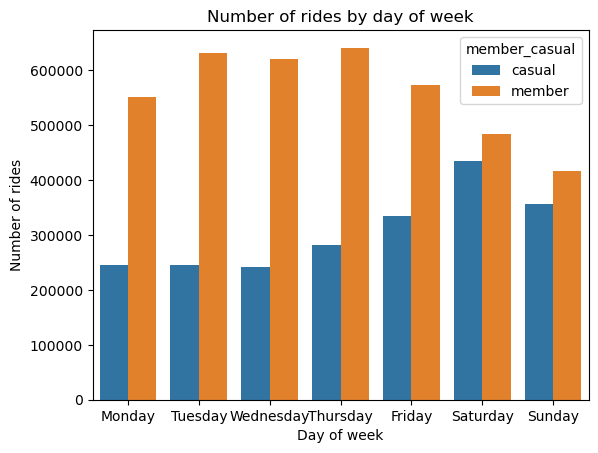

In [25]:
#The basic structure of seaborn for a bar chart is this
sns.barplot(data=rides_by_day, x='day_name', y='count', hue='member_casual') #hue is the parameter that separates the bars by color according to the type of user.
plt.title('Number of rides by day of week')
plt.xlabel('Day of week')
plt.ylabel('Number of rides')
plt.show()

The previous chart showing the number of rides by day of the week highlights even more clearly the distinct usage patterns between members and casual riders. Members consistently exceed casual riders across all days—including weekends—demonstrating a strong and sustained engagement with the service. This suggests that membership provides meaningful value and encourages frequent use. A potential strategy to attract new members would be to emphasize how a membership can enhance both convenience and cost‑effectiveness, motivating users to adopt the service as a primary mode of transportation rather than an occasional alternative.

In [26]:
avg_ride_length = df.groupby('member_casual')['ride_length'].mean().reset_index()
avg_ride_length

,member_casual,ride_length
0,casual,18.909893
1,member,11.955500


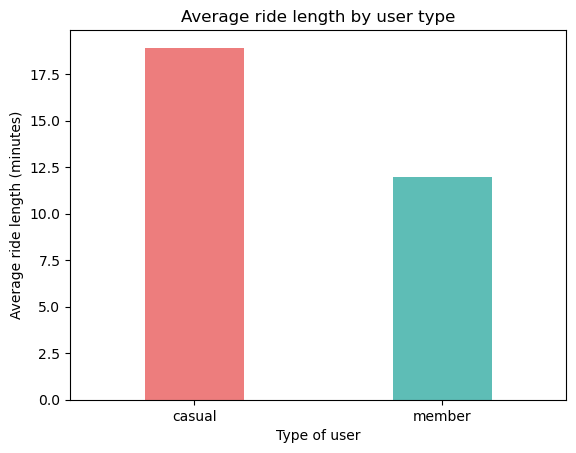

In [27]:
sns.barplot(data=avg_ride_length,width=0.4, palette=['#FF6B6B', '#4ECDC4'], x='member_casual', y='ride_length', hue='member_casual') #hue is the parameter that separates the bars by color according to the type of user.
plt.title('Average ride length by user type')
plt.xlabel('Type of user')
plt.ylabel('Average ride length (minutes)')
plt.show()

By examining the chart of average ride duration by user type, we can observe that casual riders tend to use the service for longer periods compared to annual members. This suggests that recreational use is not only highly valued but could also become one of the primary focal points for future marketing campaigns.

In [28]:
rides_by_type = df.groupby('member_casual')['rideable_type'].value_counts().reset_index()
rides_by_type

,member_casual,rideable_type,count
0,casual,electric_bike,1444387
1,casual,classic_bike,697555
2,member,electric_bike,2549435
3,member,classic_bike,1371257


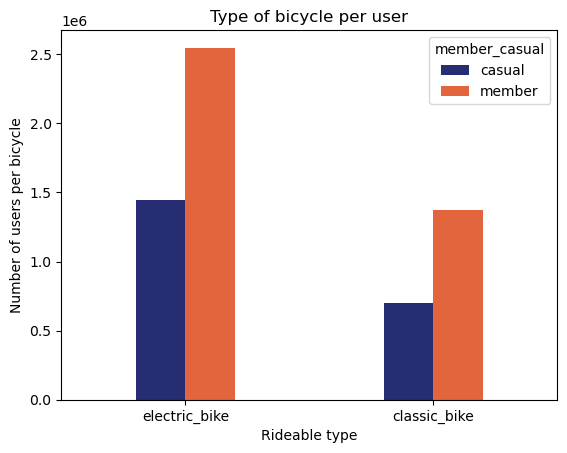

In [29]:
sns.barplot(data=rides_by_type,width=0.4, palette=['#1A237E', '#FF5722'], x='rideable_type', y='count', hue='member_casual') #hue is the parameter that separates the bars by color according to the type of user.
plt.title('Type of bicycle per user')
plt.xlabel('Rideable type')
plt.ylabel('Number of users per bicycle')
plt.show()

In the previous chart, we can observe that users in general are more attracted to using electric bikes. This trend is especially notable among annual members, which is consistent with the fact that members typically rely on the service as a daily mode of transportation rather than solely for recreational purposes. Therefore, it is reasonable to infer that they prefer a more comfortable, motor‑assisted option that reduces unnecessary physical effort. It may be worthwhile to increase the strategic focus on this type of vehicle, as it appears to be the most in demand.

## Act
1. The analysis reveals a clear trend: memberships strongly encourage frequent use of the service, making them a strategic advantage when attracting new long‑term users. However, casual riders differ fundamentally from members, as they tend to use the service primarily for leisure. This presents a significant opportunity: we can encourage these potential new members to adopt a discounted membership, provided they use the service on a daily basis. Such an approach could motivate casual riders to incorporate the service into their regular work commutes, ultimately increasing overall demand.

2. Recreational use continues to be a highly relevant factor, as shown in the analysis results: during leisure periods, users tend to engage with the service for longer durations. This represents a valuable opportunity to strengthen our positioning by establishing partnerships with complementary businesses—such as shops, cafés, restaurants, and other venues located along our service routes. Through these partnerships, we could offer attractive discounts tied to the acquisition of a membership. Such incentives would not only enhance the user experience but also encourage casual riders to transition into members, ultimately increasing overall demand.

3. An important finding relates to the type of vehicle users choose when accessing the service. The data shows a strong preference for electric bikes, likely driven by the comfort and versatility this technology provides. Casual riders, in particular, demonstrate a clear inclination toward motor‑assisted options. For this reason, it would be beneficial to increase the number of electric units across the system to ensure consistent availability at all stations.

## Share
We can identify clear behavioral differences between Cyclistic’s two main user groups. Annual members primarily use the service for purposeful, routine transportation—such as commuting to work—which explains why their highest usage levels occur on weekdays. In contrast, casual riders tend to use the service mostly on weekends, as their trips are predominantly recreational.

Additionally, casual riders typically take longer trips, reflecting the spontaneous nature of their rides, where time is not a limiting factor. Members, on the other hand, follow more structured schedules and predefined commuting routes, resulting in shorter and more consistent trip durations.

Despite these differences, both user groups show a strong preference for electric bikes. This trend is understandable: members value a reliable and efficient option for daily commuting, while casual riders appreciate the added comfort that reduces physical effort during leisure activities.